**Part** 2 — Supervised Machine Learning Model

In [31]:
#task 1 load dataset and define #task 2
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# Regression label (continuous target)
y_reg = df["Price"]

# Classification label (binary target)
y_clf = (y_reg > y_reg.median()).astype(int)

# Feature matrix
X = df.drop("Price", axis=1)

# Display information
print("Feature Matrix Shape:", X.shape)
print("Regression Label Shape:", y_reg.shape)
print("Classification Label Shape:", y_clf.shape)

print("\nMedian Price:", y_reg.median())
print("\nClassification Label Distribution:")
print(y_clf.value_counts())

Feature Matrix Shape: (1304, 11)
Regression Label Shape: (1304,)
Classification Label Shape: (1304,)

Median Price: 52054.56

Classification Label Distribution:
Price
0    653
1    651
Name: count, dtype: int64


In [3]:
df["Touchscreen"] = df["ScreenResolution"].str.contains("Touchscreen").astype(int)

print(df["Touchscreen"].value_counts())

Touchscreen
0    1112
1     192
Name: count, dtype: int64


In [7]:
y_clf = df["Touchscreen"]
X = df.drop(["Price", "Touchscreen"], axis=1)
for col in df.columns:
    if df[col].nunique() == 2:
        print(col, "->", df[col].unique())
        df["Touchscreen"] = df["ScreenResolution"].str.contains("Touchscreen").astype(int)

print(df["Touchscreen"].value_counts())

Touchscreen -> [0 1]
Touchscreen
0    1112
1     192
Name: count, dtype: int64


In [8]:
#identify categorial columns (encode categorial column)
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

# Features
X = df.drop("Price", axis=1)

# Categorical columns
cat_cols = X.select_dtypes(include="object").columns

print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')


In [9]:
#one hot encode
import pandas as pd

df = pd.read_csv("cleaned_data.csv")

# Feature matrix
X = df.drop("Price", axis=1)

# Find categorical columns
cat_cols = X.select_dtypes(include="object").columns

# One-hot encoding
X_encoded = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

print("Original Shape:", X.shape)
print("Encoded Shape:", X_encoded.shape)

X_encoded.head()

Original Shape: (1304, 11)
Encoded Shape: (1304, 522)


,sno,Inches,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,Company_Huawei,...,Weight_4.2kg,Weight_4.33kg,Weight_4.36kg,Weight_4.3kg,Weight_4.42kg,Weight_4.4kg,Weight_4.5kg,Weight_4.6kg,Weight_4.7kg,Weight_4kg
0,0,13.3,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,13.3,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,15.6,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,3,15.4,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,13.3,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
#exactly dropped
for col in cat_cols:
    categories = sorted(df[col].dropna().unique())
    print(col, "->", categories[0])
pd.get_dummies(X, columns=cat_cols, drop_first=True)
for col in cat_cols:
    categories = sorted(df[col].dropna().astype(str).unique())
    print(f"\n{col}")
    print("Dropped category:", categories[0])
    print("All categories:", categories)

Company -> Acer
TypeName -> 2 in 1 Convertible
ScreenResolution -> 1366x768
Cpu -> AMD A10-Series 9600P 2.4GHz
Ram -> 12GB
Memory -> 1.0TB HDD
Gpu -> AMD FirePro W4190M
OpSys -> Android
Weight -> 0.69kg

Company
Dropped category: Acer
All categories: ['Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi']

TypeName
Dropped category: 2 in 1 Convertible
All categories: ['2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook', 'Workstation']

ScreenResolution
Dropped category: 1366x768
All categories: ['1366x768', '1440x900', '1600x900', '1920x1080', '2560x1440', '4K Ultra HD / Touchscreen 3840x2160', '4K Ultra HD 3840x2160', 'Full HD / Touchscreen 1920x1080', 'Full HD 1920x1080', 'IPS Panel 1366x768', 'IPS Panel 2560x1440', 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160', 'IPS Panel 4K Ultra HD 3840x2160', 'IPS Panel Full HD / Touchscreen 1920x1080', 'IPS Pa

In [14]:
#task 3 leakage
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("cleaned_data.csv")

# Regression target
y_reg = df["Price"]

# Classification target
y_clf = (df["Price"] > df["Price"].median()).astype(int)

# Features
X = df.drop("Price", axis=1)

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# ---------------------------
# Regression Train-Test Split
# ---------------------------
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# ---------------------------
# Classification Train-Test Split
# ---------------------------
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

# ---------------------------
# Scaling (Regression)
# ---------------------------
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# ---------------------------
# Scaling (Classification)
# ---------------------------
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Regression Train Shape:", X_train_reg_scaled.shape)
print("Regression Test Shape :", X_test_reg_scaled.shape)

print("Classification Train Shape:", X_train_clf_scaled.shape)
print("Classification Test Shape :", X_test_clf_scaled.shape)

Regression Train Shape: (1043, 522)
Regression Test Shape : (261, 522)
Classification Train Shape: (1043, 522)
Classification Test Shape : (261, 522)


In [16]:
#task 5 classsification model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load data
df = pd.read_csv("cleaned_data.csv")

# Target
y_reg = df["Price"]

# Features
X = df.drop("Price", axis=1)

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg,
    test_size=0.2,
    random_state=42
)

# Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MSE :", mse_lr)
print("R²  :", r2_lr)
#print coeff
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

print(coef_df)
# imp feature
top3 = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=False).index
).head(3)

print("\nTop 3 Features:")
print(top3)
#ridge reg
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression")
print("MSE :", mse_ridge)
print("R²  :", r2_ridge)
#comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse_lr, mse_ridge],
    "R2": [r2_lr, r2_ridge]
})

print(comparison)

Linear Regression
MSE : 389155041.5219371
R²  : 0.7467733972306694
           Feature  Coefficient
0              sno  2856.844753
1           Inches   378.759085
2    Company_Apple  -291.326218
3     Company_Asus   872.407610
4    Company_Chuwi  -290.180774
..             ...          ...
517   Weight_4.4kg   200.544199
518   Weight_4.5kg  1558.831237
519   Weight_4.6kg  2188.201323
520   Weight_4.7kg  2137.848528
521     Weight_4kg  -958.852067

[522 rows x 2 columns]

Top 3 Features:
                         Feature   Coefficient
279    Gpu_Intel HD Graphics 620 -15651.366267
301  Gpu_Nvidia GeForce GTX 1050 -15374.440170
273    Gpu_Intel HD Graphics 520 -14052.321173

Ridge Regression
MSE : 301005085.0234886
R²  : 0.804133347987232
               Model           MSE        R2
0  Linear Regression  3.891550e+08  0.746773
1   Ridge Regression  3.010051e+08  0.804133


In [23]:
#Metrics and confussion matrix
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("cleaned_data.csv")

# ==========================
# Create Binary Target
# ==========================
y = (df["Price"] > df["Price"].median()).astype(int)

# Features
X = df.drop("Price", axis=1)

# ==========================
# Encode Categorical Columns
# ==========================
X = pd.get_dummies(X, drop_first=True)

# Convert all columns to numeric
X = X.astype(float)

# ==========================
# Train-Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# Scale Features
# ==========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# Train Logistic Regression
# ==========================
model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

# ==========================
# Predictions
# ==========================
y_pred = model.predict(X_test_scaled)

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

# ==========================
# Accuracy
# ==========================
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

# ==========================
# Precision, Recall, F1
# ==========================
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Optional: extract only Class-1 metrics
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

print("\nClass 1 Metrics")
print("Precision :", round(report['1']['precision'], 4))
print("Recall    :", round(report['1']['recall'], 4))
print("F1 Score  :", round(report['1']['f1-score'], 4))

Confusion Matrix
[[122   9]
 [ 17 113]]

Accuracy: 0.9004

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       131
           1       0.93      0.87      0.90       130

    accuracy                           0.90       261
   macro avg       0.90      0.90      0.90       261
weighted avg       0.90      0.90      0.90       261


Class 1 Metrics
Precision : 0.9262
Recall    : 0.8692
F1 Score  : 0.8968


AUC Score: 0.9618


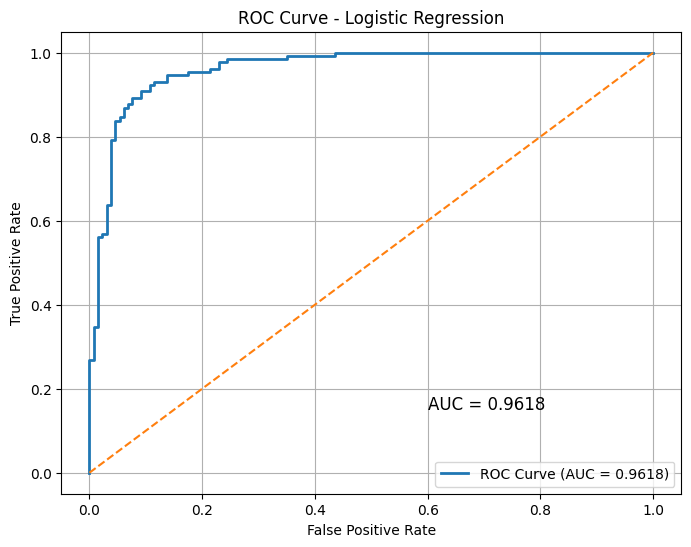

In [21]:
#task 5 a compute and plot ROC
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("cleaned_data.csv")

# ==========================
# Create Binary Target
# ==========================
y = (df["Price"] > df["Price"].median()).astype(int)

# Features
X = df.drop("Price", axis=1)

# ==========================
# Encode Categorical Columns
# ==========================
X = pd.get_dummies(X, drop_first=True)

# Convert True/False to 0/1 if present
X = X.astype(float)

# ==========================
# Train-Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# Feature Scaling
# ==========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# Logistic Regression Model
# ==========================
log_reg = LogisticRegression(max_iter=5000)

log_reg.fit(X_train_scaled, y_train)

# ==========================
# Predict Probabilities
# ==========================
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# ==========================
# ROC Curve
# ==========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# ==========================
# AUC Score
# ==========================
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", round(auc_score, 4))

# ==========================
# Plot ROC Curve
# ==========================
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {auc_score:.4f})"
)

# Random Classifier Line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.text(
    0.60,
    0.15,
    f"AUC = {auc_score:.4f}",
    fontsize=12
)

plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("roc_curve.png")
plt.show()

In [24]:
# 5 b threhold sensitivity
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicted probabilities for Class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Thresholds
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for threshold in thresholds:

    # Convert probabilities to class predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        threshold,
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ])

# Display table
results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

print(results_df)

   Threshold  Precision  Recall      F1
0        0.3     0.8897  0.9308  0.9098
1        0.4     0.9206  0.8923  0.9062
2        0.5     0.9262  0.8692  0.8968
3        0.6     0.9402  0.8462  0.8907
4        0.7     0.9474  0.8308  0.8852


In [29]:
#task 6 regularization on logistic reg
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score
)

# ==========================
# Baseline Model (C=1.0)
# ==========================
model_c1 = LogisticRegression(
    C=1.0,
    max_iter=5000,
    random_state=42
)

model_c1.fit(X_train_scaled, y_train)

y_pred_c1 = model_c1.predict(X_test_scaled)
y_prob_c1 = model_c1.predict_proba(X_test_scaled)[:, 1]

precision_c1 = precision_score(y_test, y_pred_c1)
recall_c1 = recall_score(y_test, y_pred_c1)
auc_c1 = roc_auc_score(y_test, y_prob_c1)

# ==========================
# Strong Regularization (C=0.01)
# ==========================
model_c001 = LogisticRegression(
    C=0.01,
    max_iter=5000,
    random_state=42
)

model_c001.fit(X_train_scaled, y_train)

y_pred_c001 = model_c001.predict(X_test_scaled)
y_prob_c001 = model_c001.predict_proba(X_test_scaled)[:, 1]

precision_c001 = precision_score(y_test, y_pred_c001)
recall_c001 = recall_score(y_test, y_pred_c001)
auc_c001 = roc_auc_score(y_test, y_prob_c001)

# ==========================
# Comparison Table
# ==========================
results = pd.DataFrame({
    "Model": ["Logistic Regression (C=1.0)",
              "Logistic Regression (C=0.01)"],
    "Precision": [round(precision_c1, 4),
                  round(precision_c001, 4)],
    "Recall": [round(recall_c1, 4),
               round(recall_c001, 4)],
    "AUC": [round(auc_c1, 4),
            round(auc_c001, 4)]
})
print("\n")
print(results)
print("\n")



                          Model  Precision  Recall     AUC
0   Logistic Regression (C=1.0)     0.9262  0.8692  0.9618
1  Logistic Regression (C=0.01)     0.9360  0.9000  0.9734




In [30]:
#task 7 BOOTSTRAP
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==================================================
# Load Data
# ==================================================
df = pd.read_csv("cleaned_data.csv")

# Binary target
y = (df["Price"] > df["Price"].median()).astype(int)

# Features
X = df.drop("Price", axis=1)

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Convert to numeric
X = X.astype(float)

# ==================================================
# Train-Test Split
# ==================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==================================================
# Scale Features
# ==================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==================================================
# Model 1 : C = 1.0
# ==================================================
model_c1 = LogisticRegression(
    C=1.0,
    max_iter=5000,
    random_state=42
)

model_c1.fit(X_train_scaled, y_train)

# ==================================================
# Model 2 : C = 0.01
# ==================================================
model_c001 = LogisticRegression(
    C=0.01,
    max_iter=5000,
    random_state=42
)

model_c001.fit(X_train_scaled, y_train)

# ==================================================
# Predicted Probabilities
# ==================================================
prob_c1 = model_c1.predict_proba(X_test_scaled)[:, 1]
prob_c001 = model_c001.predict_proba(X_test_scaled)[:, 1]

# ==================================================
# Bootstrap AUC Difference
# ==================================================
n_bootstrap = 500

auc_differences = []

np.random.seed(42)

for i in range(n_bootstrap):

    # Sample indices with replacement
    idx = np.random.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    y_boot = y_test.iloc[idx]

    prob1_boot = prob_c1[idx]
    prob2_boot = prob_c001[idx]

    # Skip samples containing only one class
    if len(np.unique(y_boot)) < 2:
        continue

    auc1 = roc_auc_score(y_boot, prob1_boot)
    auc2 = roc_auc_score(y_boot, prob2_boot)

    auc_differences.append(auc1 - auc2)

# ==================================================
# Confidence Interval
# ==================================================
mean_diff = np.mean(auc_differences)

lower_ci = np.percentile(
    auc_differences,
    2.5
)

upper_ci = np.percentile(
    auc_differences,
    97.5
)

print("Bootstrap Results")
print("-------------------")
print("Mean AUC Difference :", round(mean_diff, 6))
print("95% CI Lower Bound  :", round(lower_ci, 6))
print("95% CI Upper Bound  :", round(upper_ci, 6))

# ==================================================
# Interpretation
# ==================================================
if lower_ci > 0 or upper_ci < 0:
    print("\nConfidence interval excludes zero.")
    print("The performance difference is likely reliable.")
else:
    print("\nConfidence interval includes zero.")
    print("The performance difference may not be reliable.")

Bootstrap Results
-------------------
Mean AUC Difference : -0.01144
95% CI Lower Bound  : -0.023682
95% CI Upper Bound  : -0.000406

Confidence interval excludes zero.
The performance difference is likely reliable.
